In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

In [12]:
df = pd.read_csv('./data/nairobi_house_prices.csv')
df.head(10)

,Price,propertyType,Location,Bedroom,bathroom,House size,Land size
0,KSh 350 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
1,KSh 30 000 000,Vacant Land,Karen,NaN,NaN,NaN,0.5 acres
2,KSh 325 000 000,Vacant Land,Westlands,NaN,NaN,NaN,0.5 acres
3,KSh 80 000 000,Townhouse,Kitisuru,5.0,5.0,NaN,0.5 acres
4,KSh 25 500 000,Apartment,Kileleshwa,4.0,4.0,230 m²,NaN
5,KSh 300 000 000,Townhuse,Runda,6.0,6.0,NaN,0.5 acres
6,KSh 160 000 000,Townhouse,Runda,4.0,4.0,NaN,0.5 acres
7,KSh 9 500 000,Apartment,Kilimani,2.0,2.0,105 m²,NaN
8,KSh 150 000 000,Townhouse,Thigiri,4.0,4.0,NaN,0.5 acres
9,KSh 42 000 000,Apartment,Kileleshwa,4.0,4.0,280 m²,NaN


In [17]:
df.dtypes

Price               str
propertyType        str
Location            str
Bedroom         float64
bathroom        float64
House size          str
Land size           str
dtype: object

In [18]:
# Price: strip "KSh", spaces (incl. non-breaking), and any stray characters
df['Price'] = (
    df['Price']
    .astype(str)
    .str.replace(r'[^\d]', '', regex=True)   # keep only digits
    .astype('float64')
)

# House size: strip "m²" and spaces, keep NaN as NaN
df['House size'] = pd.to_numeric(
    df['House size'].astype(str).str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'   # turns "nan" (stringified) and empty strings into NaN properly
)

In [19]:
df[['Price', 'House size']].head(10)
df.dtypes

Price           float64
propertyType        str
Location            str
Bedroom         float64
bathroom        float64
House size      float64
Land size           str
dtype: object

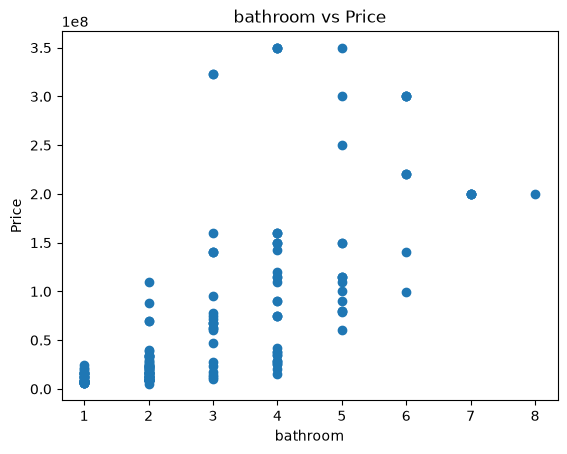

In [22]:
# visualize the data
plt.scatter(df['bathroom'], df['Price'])
plt.xlabel('bathroom')
plt.ylabel('Price')
plt.title('bathroom vs Price')
plt.show()

In [ ]:
# split the data into training and testing set
X = df[['bathroom']]
y = df['Price']